In [ ]:
%%html
<center><marquee style='width: 60%; color: blue;'><b>✌ ¡Hola a todos! Un saludo... Vamos a Empezar ✌ </b></marquee><center>

<table>
    <tr>
        <td><img src="https://raw.githubusercontent.com/Fabian830348/Bases_Datos/refs/heads/master/logo_ECI.png" width="300"/></td>
        <td>&nbsp;</td>
        <td>
            <h1 style="font-size:200%;color:blue;text-align:center">    <FONT COLOR="blue">  Clustering  </p> k-means     </h1></td>         
        <td>
            <tp><p style="font-size:99%;text-align:center">Diplomado Ciencia de Datos</p></tp>
            <tp><p style="font-size:115%;text-align:center">2026-1</p></tp>
            <tp><p style="font-size:115%;text-align:center">Prof. Fabián Sánchez</p></tp>
        </td>
    </tr>
</table>

**Objetivo de la sesión**:

En esta sesión revisaremos el método de k-means y lo aplicaremos a la agrupación o clustering.

Inicialmente, daremos los conceptos básicos del método y un ejemplo general. Luego, aplicaremos el método a un caso de estudio.


# <FONT SIZE=5 COLOR="purple"> 1. Algoritmo k-means </FONT>

**Generalidades**

Tomado de [Joaquin](https://rpubs.com/Joaquin_AR/310338) y de [Sklearn](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html)

- La base de $k$-means fue propuesta por *Stuart Lloyd* en 1957 para la modulación por impulsos codificados. Luego evolucionó con la idea de *Hugo Steinhaus*.

- El término $k$-means clustering fue utilizado por primera vez por *MacQueen en 1967*, es uno de los algoritmos de agrupamiento más simples y más utilizados.

- Es uno de los métodos no supervisados que se usa para dividir un conjunto de individuos (registros del Conjunto de Datos) en un conjunto de $k$ grupos (es decir, ***$k$ clusters***), donde $k$ representa el número de grupos preestablecidos. Este algoritmo busca que los objetos ***dentro del mismo cluster*** sean lo más similares posibles (es decir, alta similitud intraclase), mientras que ***distintos clusteres*** sean lo más diferente posible (es decir, baja similitud entre clases).

- En el $k$-means clustering, cada grupo está representado por su centro (es decir, ***centroide***) que corresponde a la media de puntos asignados al ***cluster***.

- $k$-means clustering encuentra los $k$ mejores clústeres, entendiendo como mejor clúster aquel cuya varianza interna (within-cluster variation) sea lo más pequeña posible.

- Se trata por lo tanto de un problema de optimización, en el que se reparten las observaciones en $k$ clusters de forma que la suma de las varianzas internas de todos ellos sea lo menor posible. Para poder solucionar este problema es necesario definir un modo de cuantificar la varianza interna, que veremos más adelante.

<br>
<center><img src="https://miro.medium.com/v2/resize:fit:1400/format:webp/1*JsfEdbXKwJw_Euprvx17KA.png?raw=true" alt="centered image" width="500" height="300"></center> <center><figcaption> <FONT SIZE=1 COLOR="black"> Fuente: https://miro.medium.com  </FONT> <figcaption></center>
<br>

**Pasos del Algoritmo de k-means**

1. El primer paso es fijar el número $k$  de clusters que se desean obtener.

2. El algoritmo comienza seleccionando aleatoriamente $k$ puntos del conjunto de datos para que sirvan como centroides iniciales de los cluster.

3. Cada punto del conjunto de datos se asigna al cluster cuyo centroide esté más cercano. Esto se hace usualmente con la distancia euclideana. Es decir, que si $\{\mu_1^{1}, \mu_2^{1}, \dots, \mu_k^{1}\}$ son los centroides iniciale, el punto $x_i$ se asigna al cluster cuyo centroide minimiza

$$ \|x_i-\mu_j^{1} \| \quad 1 \leq j \leq k\}$$

En otras palabras

$$Cluster(x_i) = argmin_j  \|x_i-\mu_j^{1} \|$$

Este proceso se repite para todos lo puntos del conjunto.

Cuando se identifica el centroide más cercano, el punto $x_i$ se asigna al cluster correspondiente a ese centroide.

4. Ahora, vamos a actualizar los centroides. El nuevo centroide se actualiza mediante la media aritmética de los puntos asociados al cluster. Es decir,

$$\mu_i^{2}= \dfrac{1}{|C_{i}^{2}|}\sum \limits_{x_j \in C_i^{2}} x_j$$

y en general,

$$\mu_i^{t+1}= \dfrac{1}{|C_{i}^{t}|}\sum \limits_{x_j \in C_i^{t}} x_j$$

donde $C_i^{t}$ es el cluster $i$ en la iteración $t$ y $|C_{i}^{t}|$ es el número de elementos de ese cluster.

Aca nos preguntamos, ¿cuando debemos parar?

5. En este punto vamos a tratar la función objetivo del algoritmo.

Tenemos que $\{C_1,C_2, \dots, C_k\}$, $k$ conjuntos que contienen las observaciones del conjunto de datos, tales que:

- $C_1 \cup C_2 \cup \dots \cup C_k = {1,2,3, \dots, k}$. Cada observación pertence a uno de los $k$ clusters.

- $C_i \cap C_j = \emptyset $, para $i \neq j$. Es decir, que un registro no puede estar en diferentes clusters.

El objetivo de k-means es consiste en definir grupos de modo que el total de la variación **intra-cluster** sea mínima. A esta cantidad se le conoce como: ***inertia*** o  **within-cluster sum-of-squares** y está definida mediante:

$$WCSS =\sum_{n=1}^{k} W(C_n)= \sum_{n=1}^{k} \sum_{x_i \in C_{n}}||x_i -\mu_n||^2$$

donde,

 - $W(C_k) = \sum_{x_i \in C_{k}}||x_i -\mu_k||^2$

 - $x_i$ es un registro que pertence al cluster $C_k$.

 - $\mu_k$ es el valor promedio de los registros asignados al cluster $C_k$

El algoritmo $k$-means tiene como objetivo elegir ***centroides*** que minimicen la ***inercia***. Esto mide la compacidad del agrupamiento y se quiere que sea lo mas baja posible.

Finalmente, podemos formular el problema mediante:

$$ \min  E(\mu_i)  = \min \sum \limits_{i=1}^{k} \sum \limits_{x_i \in C_n} \|x_i -\mu_n \|^2$$

donde $C$ es el conjunto de datos cuyos elementos son los objetos $x_i$ representados por vectores y cada uno de sus elementos representa una característica o atributo. Tenemos $k$ clusters o grupos con su correspondiente centroide $\mu_n$.

En cada actualización de los centroides, desde el punto de vista matemático, debemos poner una condición necesaria de extremo a la función $E(\mu_i)$

$$\dfrac{\partial E}{\partial \mu_n}=0$$

se puede demostrar que:

$$\mu_i^{(t+1)} = \dfrac{1}{|C_i^{(t)}|} \sum \limits_{x_j \in C_i^{(t)}}x_j$$.





# <FONT SIZE=5 COLOR="purple"> 2. Ejemplo de la idea general </FONT>

Primero, vamos a cargar las librerías.

In [34]:
# librerías para procesar
import numpy  as np
import pandas as pd

# librerías para graficar
import matplotlib.pyplot as plt
import seaborn           as sns
import plotly.express    as px

# Algunos elementos de preprocesamiento: escalamiento y selección de k en k-means
from sklearn.preprocessing     import StandardScaler
from sklearn.metrics           import silhouette_samples, silhouette_score

# Para el algoritmo k-means
from sklearn.cluster           import KMeans

# Para otros algoritmos de machine learning
from sklearn.decomposition     import PCA
from sklearn.neighbors         import KNeighborsClassifier
from sklearn.neighbors         import NearestNeighbors
from sklearn.metrics           import pairwise_distances_argmin_min

#Para omitir los warnings
import warnings
warnings.filterwarnings("ignore")

El siguiente código genera un gráfico interactivo que permite mover el número de clusters.

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import ipywidgets as widgets
from ipywidgets import interact

# Datos de ejemplo para clustering
np.random.seed(7)
x1 = np.random.standard_normal((100,2))*0.6+np.ones((100,2))
x2 = np.random.standard_normal((100,2))*0.5-np.ones((100,2))
x3 = np.random.standard_normal((100,2))*0.4-2*np.ones((100,2))+5
X = np.concatenate((x1,x2,x3),axis=0)

# Función para actualizar el gráfico de clustering según el valor de n
def actualizar_cluster(n):
    # Crear y ajustar el modelo K-means
    k_means = KMeans(n_clusters=n, random_state=0)
    k_means.fit(X)

    # Obtener centroides y etiquetas
    centroides = k_means.cluster_centers_
    etiquetas = k_means.labels_

    # Graficar los clusters
    plt.figure(figsize=(8, 6))
    colores = ['r', 'b', 'g', 'c', 'm', 'y', 'k']  # Diferentes colores para cada cluster
    for i in range(n):
        plt.plot(X[etiquetas == i, 0], X[etiquetas == i, 1], colores[i % len(colores)] + '.', label=f'Cluster {i+1}')

    # Graficar los centroides
    plt.plot(centroides[:, 0], centroides[:, 1], 'mo', markersize=10, label='Centroides')
    plt.title(f'Número de clusters: {n}\nInercia: {round(k_means.inertia_, 2)}')
    plt.legend(loc='best')
    plt.xlabel('Eje X')
    plt.ylabel('Eje Y')
    plt.show()

# Crear el control deslizante para el número de clusters
u = interact(actualizar_cluster, n=widgets.IntSlider(value=3, min=1, max=10, step=1, description='Clusters'))


interactive(children=(IntSlider(value=3, description='Clusters', max=10, min=1), Output()), _dom_classes=('wid…

In [ ]:
!pip install imageio

Vamos a ilustrar como el método selecciona los centroides dependiendo del número del clústers

# <FONT SIZE=5 COLOR="purple"> 3. ¿Cuántos clúster debemos seleccionar? </FONT>


- Determinar el número óptimo de clusters en un conjunto de datos es un problema fundamental en el agrupamiento. En $k$-means se requiere especificar de antemano el número de clusters $k$ que se generarán.

- Desafortunadamente no hay una respuesta definitiva a esta pregunta. El número óptimo de clusters es algo subjetivo y depende del método utilizado para medir
similitudes y los parámetros utilizados para la partición.

Vamos a describir dos métodos para determinar el número óptimo de clusters para $k$-means: ***elbow method*** y ***silhouette***





## <FONT SIZE=4 COLOR="green"> 3.1 El método del codo </FONT>

La idea básica detrás del método $k$-means, es definir el número de clusters que minimizan la inercia ***WCSS***. Recordemos que ***WCSS*** mide la compacidad del agrupamiento y queremos que sea lo más pequeño posible.

El **método codo** analiza el ***WCSS*** como una función del número de clusters. Se debe elegir una cantidad de clusters de tal forma que agregar otro cluster no mejore, en gran medida, el valor ***WCSS***.

El número óptimo de clusters se puede definir de la siguiente manera:

1. Calcule el algoritmo de clustering $k$-means para diferentes valores de $k$. Por ejemplo, puede variar $k$ de 1 a 10 grupos.

2. Para cada $k$, calcule ***WCSS***.

3. Trazar la curva de ***WCSS*** según el número de clusters $k$.

4. La ubicación de una curva (codo) en el plot generalmente se considera como un indicador del número adecuado de clusters.

Tenga en cuenta que el método del codo a veces es ambigüo.

El método del codo utiliza la distancia media de las observaciones a su centroide. Es decir, se fija en las distancias intra-cluster. Cuanto más grande es el número de clusters $k$, la varianza intra-cluster tiende a disminuir. Cuanto menor es la distancia intra-cluster mejor, ya que significa que los clusters son más compactos. El método del codo busca el valor $k$ que satisfaga que un incremento de $k$, no mejore sustancialmente la distancia media intra-cluster.
[ver](https://machinelearningparatodos.com/segmentacion-utilizando-k-means-en-python/)


<center><img src="https://github.com/Fabian830348/cursos/blob/a78eef65f7afa2e9096475bf1860843870f52276/Imagen/elbow.png?raw=true" alt="centered image" width="400" height="250"></center>

El punto en el que se observa ese cambio brusco en la inercia nos dirá el número óptimo de clusters a seleccionar para ese conjunto de datos; o dicho de otra manera: el punto que representaría al codo del brazo será el número óptimo de clusters para ese conjunto.

"within= [] ## Elbow Graph (codo), se tiende a elegir muchos grupos
for k in range(1,10):
    kmeanModel = KMeans(n_clusters=k).fit(nuevosACP)
    within.append(kmeanModel.inertia_)
fig=px.line(x=list(range(1,10)), y=within)
fig.show()


## <FONT SIZE=4 COLOR="green"> 2.2 El método de la Silueta </FONT>

- El coeficiente de silueta mide qué tan bien se agrupa una observación y estima la ***distancia promedio entre clusters***.

- El gráfico de la silueta muestra una medida de qué tan cerca está cada punto en un cluster de los puntos en los clusters vecinos.

Para cada observación $i$, el ancho de la silueta $s_i$ se calcula de la siguiente manera:

1. Para cada observación $i$, calculamos la disimilitud (distancia) promedio $a_i$, entre $i$ y todos los otros puntos del cluster al que pertenezca $i$.

$$a_i = \dfrac{1}{|C_i|-1} \sum \limits_{j \in C_i , i\neq j} d(i,j)$$

esto es, la distancia media entre $i$ y los otros puntos del mismo clúster. *¿Por qué se divide por esa expresión?*

2. Para todos los demás clusters $C$, a los que no pertenezca $i$, calcule el promedio de disimilitud $d(i,C)$ de $i$ con todos los puntos de $C$. La menor de estas $d(i,C)$ se define como $b_i = min_C\  d(i,C)$. El valor de $b_i$ puede verse como la disimilitud promedio entre $i$ y su cluster "vecino", es decir, el más cercano al que ***no*** pertenece.

$$b_i = \min \limits_{k \neq i}\dfrac{1}{|C_k|} \sum \limits_{j \in C_k} d(i,j)$$

3. Finalmente, el ancho de la silueta de la observación $i$ se define mediante la fórmula:

$$S_i = \frac{(b_i - a_i)}{max\{a_i, b_i\}}$$

El ancho de la silueta se puede interpretar de la siguiente manera:

- Primero, este valor está entre $-1$ y $1$.

- Las observaciones con un $S_i$ cercano a 1 están muy bien agrupadas.

- Un $S_i$ pequeño (alrededor de 0) significa que la observación se encuentra entre dos grupos.

- Las observaciones con un $S_i$ negativo probablemente estén ubicadas en el cluster incorrecto.

El algoritmo es similar al método del codo y se puede calcular de la siguiente manera:

1. Calcule el algoritmo $k$-means  para diferentes valores de $k$. Por ejemplo, variando $k$ de 1 a 10 grupos.

2. Para cada $k$, calcule la silueta promedio de las observaciones.

3. Trazar el gráfico según el número de clusters y la silueta promedio.

4. La ubicación del máximo se considera como el número apropiado de clusters.

# <FONT SIZE=5 COLOR="purple"> 4. Ejemplo de k-means </FONT>

Vamos a importar los siguientes datos que contienen información sobre algunos delitos y el tamaño de la población urbana en estados de USA. El objetivo es buscar agrupar los datos que tal manera que los elementos de los cluster tengan información común que los pueda caracterizar.

## <FONT SIZE=4 COLOR="green"> 4.1 Carga y Exploración </FONT>

In [36]:
# Traemos los datos de la url.
USArrests = pd.read_csv("https://raw.githubusercontent.com/Fabian830348/Bases_Datos/refs/heads/master/usarrests.csv", index_col=0)
USArrests.head()

,Murder,Assault,UrbanPop,Rape
Alabama,13.2,236,58,21.2
Alaska,10.0,263,48,44.5
Arizona,8.1,294,80,31.0
Arkansas,8.8,190,50,19.5
California,9.0,276,91,40.6


Primero, hacemos una exploración rápida de los datos

In [37]:
# tamaño de los datos
USArrests.shape

(50, 4)

In [38]:
# información de datos faltantes
USArrests.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50 entries, Alabama to Wyoming
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Murder    50 non-null     float64
 1   Assault   50 non-null     int64  
 2   UrbanPop  50 non-null     int64  
 3   Rape      50 non-null     float64
dtypes: float64(2), int64(2)
memory usage: 4.0+ KB


No hay datos faltantes. Veamos algunas estadísticas

In [39]:
# estadísticas de los datos
USArrests.describe()

,Murder,Assault,UrbanPop,Rape
count,50.00000,50.000000,50.000000,50.000000
mean,7.78800,170.760000,65.540000,21.232000
std,4.35551,83.337661,14.474763,9.366385
min,0.80000,45.000000,32.000000,7.300000
25%,4.07500,109.000000,54.500000,15.075000
50%,7.25000,159.000000,66.000000,20.100000
75%,11.25000,249.000000,77.750000,26.175000
max,17.40000,337.000000,91.000000,46.000000


Es importante escalar los datos ya que estamos trabajando con distancias entre elementos del conjunto de datos.

In [50]:
# Escalamos los datos
scaler = StandardScaler()
scaler.fit(USArrests)
USArrests_escalados = pd.DataFrame(scaler.transform(USArrests),
                                   columns = USArrests.columns,
                                   index = USArrests.index)
USArrests_escalados.head(6)

,Murder,Assault,UrbanPop,Rape
Alabama,1.255179,0.790787,-0.526195,-0.003451
Alaska,0.513019,1.118060,-1.224067,2.509424
Arizona,0.072361,1.493817,1.009122,1.053466
Arkansas,0.234708,0.233212,-1.084492,-0.186794
California,0.281093,1.275635,1.776781,2.088814
Colorado,0.025976,0.402909,0.869548,1.883901


## <FONT SIZE=4 COLOR="green"> 4.2 Generación del modelo con $k=2$ </FONT>

Inicialmente, aplicaremos el algoritmo *kmeans* con dos clusters.

In [51]:
# generación del modelo con dos clusters
n = 2
kmeans = KMeans(n_clusters=n,                  #Número de clusters
                random_state=0)                #Semilla aleatoria.
kmeans.fit(USArrests_escalados)

KMeans(n_clusters=2, random_state=0)

Revisamos los atributos, es decir, la inercia y los centroides de los clústers.

In [54]:
# Inertia y centroides
print(kmeans.inertia_)
centroides = pd.DataFrame(kmeans.cluster_centers_, columns = USArrests_escalados.columns)
centroides

104.96163315756873


,Murder,Assault,UrbanPop,Rape
0,1.015137,1.024120,0.199591,0.855564
1,-0.676758,-0.682747,-0.133061,-0.570376


Veamos los labels (etiquetas de grupos) que genera el modelo.

In [55]:
# Atributos.
print(kmeans.labels_)

[0 0 0 1 0 0 1 1 0 0 1 1 0 1 1 1 1 0 1 0 1 0 1 0 0 1 1 0 1 1 0 0 0 1 1 1 1
 1 1 0 1 0 0 1 1 1 1 1 1 1]


Ponemos está información en el DataFrame con la información del conjunto de datos

In [56]:
df_2_cluster = USArrests.copy()
df_2_cluster["cluster"] = kmeans.labels_
df_2_cluster.head(8)

,Murder,Assault,UrbanPop,Rape,cluster
Alabama,13.2,236,58,21.2,0
Alaska,10.0,263,48,44.5,0
Arizona,8.1,294,80,31.0,0
Arkansas,8.8,190,50,19.5,1
California,9.0,276,91,40.6,0
Colorado,7.9,204,78,38.7,0
Connecticut,3.3,110,77,11.1,1
Delaware,5.9,238,72,15.8,1


Veamos la media en cada uno de los clusters

In [57]:
df_2_cluster.groupby(by = ["cluster"]).mean()

,Murder,Assault,UrbanPop,Rape
cluster,,,,
0,12.165,255.250000,68.400000,29.165000
1,4.870,114.433333,63.633333,15.943333


Además, podemos visualizar, hasta en tres dimensiones, como se comportan los clusters.

In [58]:
fig = px.scatter_3d(df_2_cluster, x='Assault', y='UrbanPop', z='Murder', color = "cluster")
fig.show()
fig.write_html("/content/file.html")

Analicemos un poco los grupos. Para esto vamos a realizar los diagramas de cajas

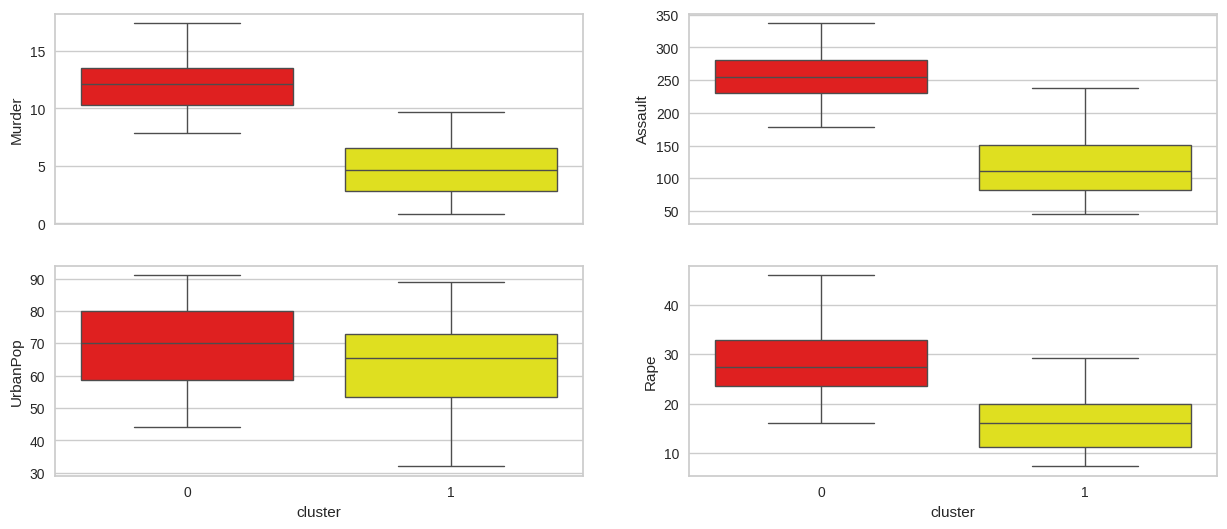

In [60]:
## Caso 2 clusters
plt.rcParams["figure.figsize"] = (15,6)
## Box-plots
fig, axes = plt.subplots(2,2, sharex=True)
## Gráfica
my_colors = {'0': 'red', '1': 'yellow'}
sns.boxplot(df_2_cluster , x = "cluster", y = "Murder", palette = my_colors, ax = axes[0,0])
sns.boxplot(df_2_cluster , x = "cluster", y = "Assault",  palette = my_colors,ax = axes[0,1])
sns.boxplot(df_2_cluster , x = "cluster", y = "UrbanPop", palette = my_colors, ax = axes[1,0])
sns.boxplot(df_2_cluster , x = "cluster", y = "Rape", palette = my_colors, ax = axes[1,1])

plt.show()

***Comentarios:***

1. El cluster 1 tiene una alta tasa delictiva y predomina la población urbana.

2. El cluster 0 tiene tasas bajas de delitos y una menor tasa que el cluster 1 de población urbana.

Note que la solución en este caso es bastante simple, pues solo está teniendo en consideración las tasas de crimenes altos con "población urbana" y tasa de crimenes bajos con "población rural". Esta solución parece ser buena, pues logra identificar los estados que tienen alto y bajo crimen.

## <FONT SIZE=4 COLOR="green"> 4.3 Selección de $k$ </FONT>

Para la selección del número de clústers $k$ usaremos:

- Método del codo
- Método de la silueta.

Para el método del codo podemos hacer la iteración sobre el número de grupos $k$ y generar la inercia $within$ y luego, representar gráficamente.

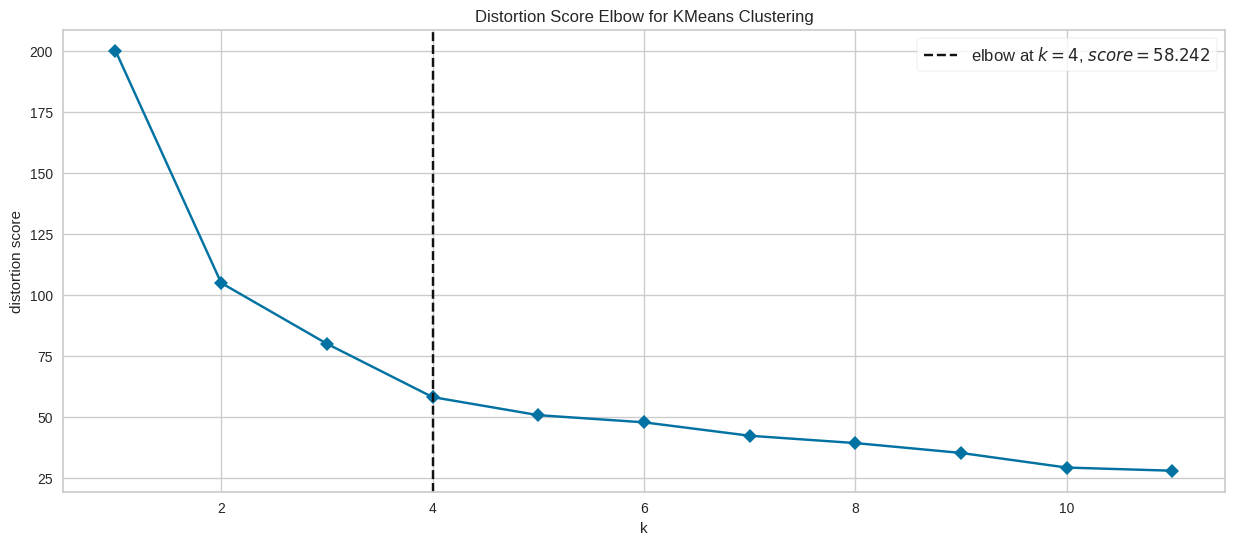

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [67]:
from yellowbrick.cluster import KElbowVisualizer
model = KMeans(random_state=0)                                          # definimos el modelo
visualizer = KElbowVisualizer(model,                      # definimos el visualizador
                              k=(1,12),                   # intervalo de los valores de k
                              timings=False)              # para que no aparezca fit-time
visualizer.fit(USArrests_escalados)                                        # Entrenamos con los datos
visualizer.show(show=False)                               # mostramos la gráfica


Según el gráfico anterior podemos usar, por ejemplo, $k=2$ o $k=4$. Sin embargo, el último valor parece más apropiado ya que para los valores siguientes el cambio en la inercia es menor.

Ahora, veamos que nos sugiere el método de la silueta

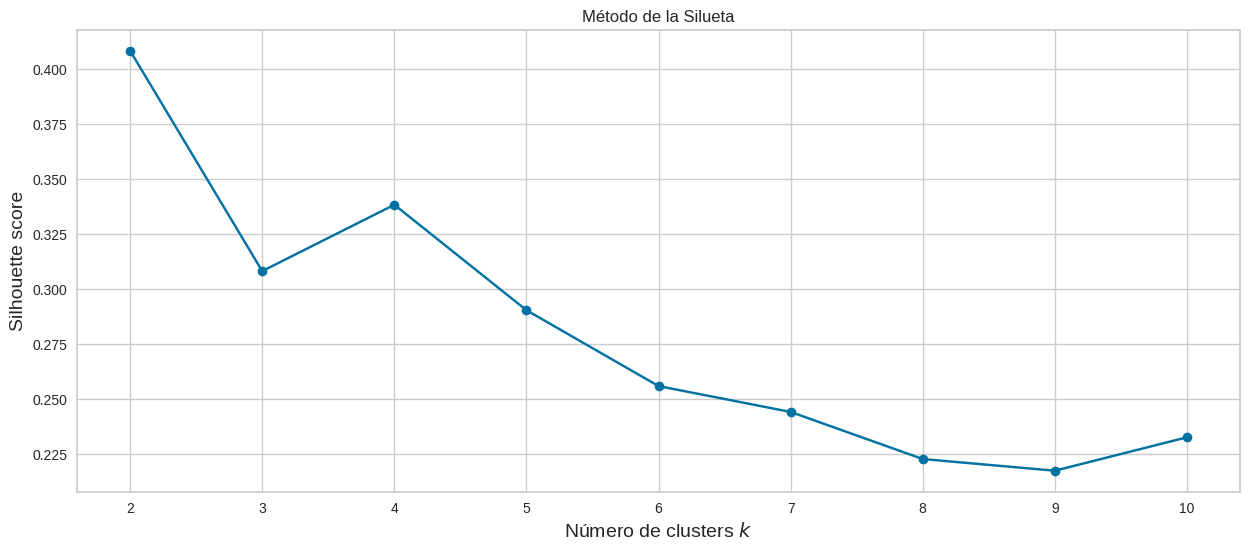

In [68]:
# generación de los modelos para diferentes valores de $k$
models = [KMeans(n_clusters=n, random_state=0 ).fit(USArrests_escalados) for n in range(2,11)]
silhouette_scores = [silhouette_score(USArrests_escalados, model.labels_) for model in models]

# gráficamos los valores de la silueta para cada valor de k
plt.plot(list(range(2, 11)), silhouette_scores, "bo-")
plt.xlabel("Número de clusters $k$", fontsize=14)
plt.ylabel("Silhouette score", fontsize=14)
plt.title("Método de la Silueta")
plt.show()

En esta gráfica buscamos los "picos" que representan incrementos del coeficiente de la silueta.

Ahora, vamos a repetir el ejercicio con $k=4$ clusters.

In [69]:
n = 4                                   # número de clusters
kmeans_4 = KMeans(n_clusters=n,         # Definir el modelo
                  random_state=0)       # Semilla aleatoria.
kmeans_4.fit(USArrests_escalados)       # Entrenar el modelo

KMeans(n_clusters=4, random_state=0)

In [70]:
# Revisamos los atributos importantes del modelo: inercia y los centroides
print(kmeans_4.inertia_)
print(kmeans_4.cluster_centers_)

58.24158433134323
[[ 0.75759426  1.13128272  0.94567938  1.22798509]
 [-0.44878894 -0.35858791  0.56576856 -0.20455729]
 [-0.97130281 -1.11783581 -0.93954982 -0.97657842]
 [ 1.32475684  0.90930557 -0.86737678  0.29612861]]


Colocaremos la información en un DataFrame y luego haremos las gráficas de los boxplots para hacer el análisis.

In [71]:
#4 Caso 4 clusters
df_4_cluster = USArrests.copy()
df_4_cluster["cluster"] = kmeans_4.labels_
df_4_cluster.head(8)

,Murder,Assault,UrbanPop,Rape,cluster
Alabama,13.2,236,58,21.2,3
Alaska,10.0,263,48,44.5,3
Arizona,8.1,294,80,31.0,0
Arkansas,8.8,190,50,19.5,3
California,9.0,276,91,40.6,0
Colorado,7.9,204,78,38.7,0
Connecticut,3.3,110,77,11.1,1
Delaware,5.9,238,72,15.8,1


Repetimos los gráficos de cajas

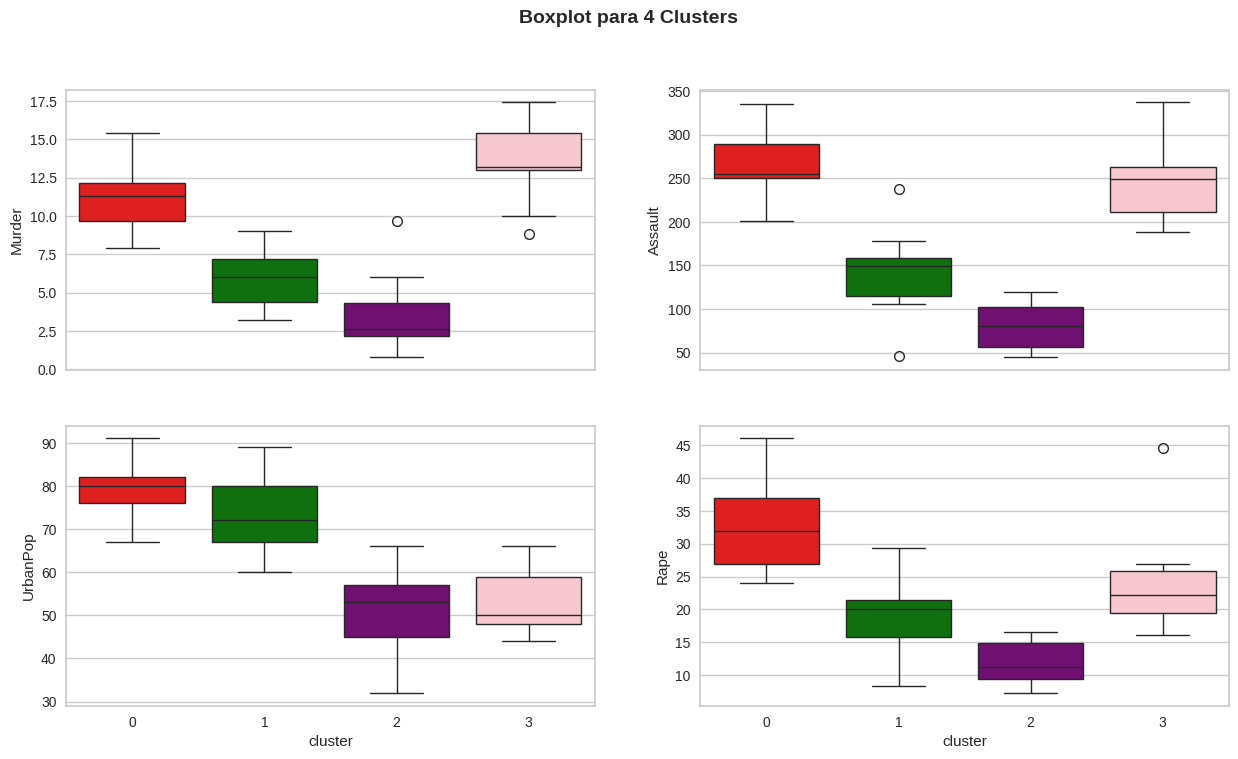

In [72]:
# Box-plots
plt.rcParams["figure.figsize"] = (15,8)
fig, axes = plt.subplots(2,2, sharex=True)
my_colors2 ={"0": "red" , "1" : "green" , "2" : "purple" , "3" : "pink"}
sns.boxplot(df_4_cluster, x = "cluster", y = "Murder",palette = my_colors2, ax = axes[0,0])
sns.boxplot(df_4_cluster, x = "cluster", y = "Assault",palette = my_colors2, ax = axes[0,1])
sns.boxplot(df_4_cluster, x = "cluster", y = "UrbanPop", palette = my_colors2,ax = axes[1,0])
sns.boxplot(df_4_cluster, x = "cluster", y = "Rape", palette = my_colors2,ax = axes[1,1])
fig.suptitle("Boxplot para 4 Clusters", fontsize=14, fontweight="bold",)
plt.show()

***Comentarios:***


1. El cluster 3 tiene alto el índice de asesinatos. El cluster 2 tiene un menor índice de asesinatos.

2. *Assault* y *Murder*  tiene un comportamiento similar para los clusters.

4. Note que el cluster 1 tiene una tasa más alta de asaltos que el cluster 3. A su vez el cluster 3 tiene más asesinatos. Los clusters 0 y 2 tiene un compartamiento similar en ambas features (*Assault* y *Murder*).

5. En cuanto a *UrbanPop* el cluster 0 y tienen cluster 1 tiene las tasas más altas. Por su supuesto los individuos en los cluster 2 y 3 tiene una tasa baja de población urbana.

Note que podemos caracterizar los cluster así:

- ***Cluster 0:*** Baja tasa de delitos, y una alta tasa de población urbana.

- ***Cluster 1.*** Alta tasa en todas las features.

- ***Cluster 2.*** Baja tasa en todas las features.

- ***Cluster 3.*** Alta tasa de `Murder` y `Assault` con baja tasa de población urbana y violaciones.

Esta solución parece ser buena, en este caso podemos pensar en una segmentación basados en la feature *UrbanPop*, note que acá tenemos más información que con 2 clusters.

Silhouette promedio: 0.3383540422958314


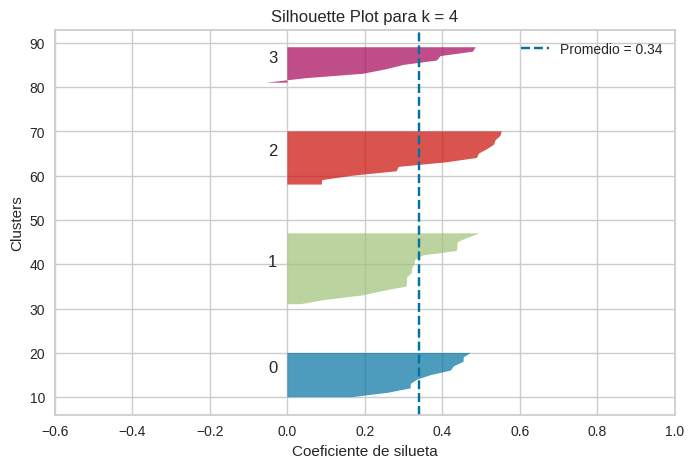

In [75]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_samples, silhouette_score

labels = kmeans_4.labels_

silhouette_avg = silhouette_score(USArrests_escalados, labels)
print("Silhouette promedio:", silhouette_avg)

sample_silhouette_values = silhouette_samples(USArrests_escalados, labels)

k = len(np.unique(labels))

fig, ax = plt.subplots(figsize=(8, 5))

y_lower = 10

for i in range(k):
    ith_cluster_values = sample_silhouette_values[labels == i]
    ith_cluster_values.sort()

    size_cluster_i = ith_cluster_values.shape[0]
    y_upper = y_lower + size_cluster_i

    ax.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        ith_cluster_values,
        alpha=0.7
    )

    ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

    y_lower = y_upper + 10

ax.axvline(
    x=silhouette_avg,
    linestyle="--",
    label=f"Promedio = {silhouette_avg:.2f}"
)

ax.set_title("Silhouette Plot para k = 4")
ax.set_xlabel("Coeficiente de silueta")
ax.set_ylabel("Clusters")
ax.set_xlim([-0.6, 1])
ax.legend()

plt.show()

La línea punteada es el score promedio de todos los puntos

$$Promedio\_silhouette = \dfrac{1}{n} \sum \limits_{i=1}^n s(i)$$

donde:

- $s(i)$ es la silueta en cada punto.

- $n$ es el número de datos

**Interpretación**

El eje $X$ representa el coeficiente de silueta, cuyo rango es
$$-1≤s(i)≤1$$

- Cerca de 1: el punto está muy bien asignado a su clúster.
- Cerca de 0: el punto está en la frontera entre dos clústeres.
- Negativo: probablemente pertenece a otro clúster.
- La línea azul punteada indica el coeficiente de silueta promedio, que en este caso es aproximadamente $0.34$

Un valor promedio de 0.34 indica que la estructura de los clústeres aceptable

| Silhouette promedio | Interpretación       |
| ------------------- | -------------------- |
| >0.70               | Excelente separación |
| 0.50–0.70           | Buena                |
| 0.25–0.50           | Aceptable            |
| <0.25               | Débil                |

El gráfico de silueta obtenido para k=4 muestra un coeficiente promedio de aproximadamente 0.34, lo que indica una calidad de agrupamiento moderada. Todos los clústeres presentan coeficientes de silueta predominantemente positivos, evidenciando que las observaciones se encuentran, en general, más próximas a los elementos de su propio grupo que a los de los grupos vecinos. El clúster 2 exhibe los mayores coeficientes de silueta, indicando una mayor cohesión y separación respecto de los demás, mientras que los clústeres 0, 1 y 3 muestran una estructura adecuada, aunque con algunas observaciones cercanas a la frontera entre grupos. En conjunto, el análisis de silueta respalda la selección de k=4 como una partición apropiada para los datos.


Veamos ahora cómo se hace una nueva clasificación

In [84]:
X_nuevo = np.array([[13,	250,	47,	20]])
X_nescalado = scaler.transform(X_nuevo.reshape(1, -1))
new_labels = kmeans_4.predict(X_nescalado)
print(new_labels)

[3]


In [87]:
from sklearn.metrics import pairwise_distances

# Distancias a todas las observaciones
distancias = pairwise_distances(X_nescalado, USArrests_escalados)

# índices ordenados de menor a mayor distancia
vecinos = np.argsort(distancias[0])

print(vecinos[:5])      # los 10 vecinos más cercanos

[39  0 23 32  3]


In [88]:
df_4_cluster.iloc[vecinos[:5]]

,Murder,Assault,UrbanPop,Rape,cluster
South Carolina,14.4,279,48,22.5,3
Alabama,13.2,236,58,21.2,3
Mississippi,16.1,259,44,17.1,3
North Carolina,13.0,337,45,16.1,3
Arkansas,8.8,190,50,19.5,3


# <FONT SIZE=5 COLOR="purple"> 5. Ejemplo 2 de k-means </FONT>

Vamos a revisar el siguiente conjunto de dígitos

In [89]:
from sklearn.datasets import load_digits
from PIL import Image

In [90]:
digits = load_digits()
data = digits.data

Vamos un elemento de este conjunto

In [91]:
data[1]

array([ 0.,  0.,  0., 12., 13.,  5.,  0.,  0.,  0.,  0.,  0., 11., 16.,
        9.,  0.,  0.,  0.,  0.,  3., 15., 16.,  6.,  0.,  0.,  0.,  7.,
       15., 16., 16.,  2.,  0.,  0.,  0.,  0.,  1., 16., 16.,  3.,  0.,
        0.,  0.,  0.,  1., 16., 16.,  6.,  0.,  0.,  0.,  0.,  1., 16.,
       16.,  6.,  0.,  0.,  0.,  0.,  0., 11., 16., 10.,  0.,  0.])

Observe que son los valores de colores en escalas de grises. Podemos cambiar la escala

In [92]:
data = 255-data

In [ ]:
data[1]

array([255., 255., 255., 243., 242., 250., 255., 255., 255., 255., 255.,
       244., 239., 246., 255., 255., 255., 255., 252., 240., 239., 249.,
       255., 255., 255., 248., 240., 239., 239., 253., 255., 255., 255.,
       255., 254., 239., 239., 252., 255., 255., 255., 255., 254., 239.,
       239., 249., 255., 255., 255., 255., 254., 239., 239., 249., 255.,
       255., 255., 255., 255., 244., 239., 245., 255., 255.])

Veamos el elemento gráfico

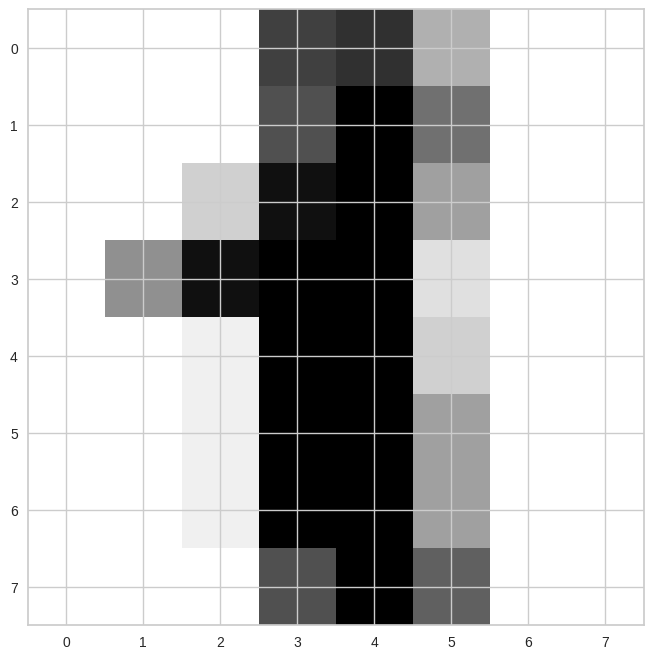

In [93]:
imagen = data[1, ]
imagen = imagen.reshape(8, 8)
plt.imshow(imagen, cmap=plt.cm.gray)

Veamos más elementos

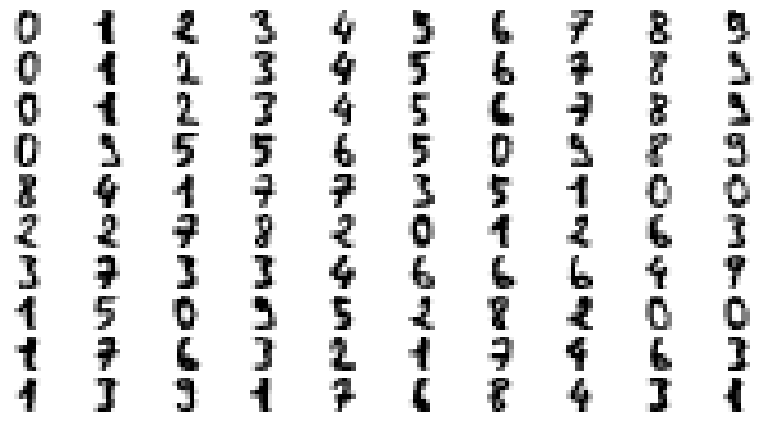

In [94]:
plt.figure(figsize=(10,10))
for k in range(0, 100):
  plt.subplot(19, 10, k+1)
  imagen = data[k, ]
  imagen = imagen.reshape(8, 8)
  plt.imshow(imagen, cmap=plt.cm.gray)
  plt.axis('off')
plt.show()

In [ ]:
print(data.shape)

El objetivo del ejercicio es utilizar *k-means* para agrupar los dígitos.

In [95]:
# fijamos una semilla
np.random.seed(1)

# Generamos el modelo
kmeans = KMeans(n_clusters=10,
                init='random')
kmeans.fit(data)
predict = kmeans.predict(data)

In [96]:
# elementos donde se cumple que el clúster es 1
fila = np.where(predict==1)[0]
fila

array([   3,   13,   23,   45,   59,   60,   62,   63,   83,   89,   91,
         92,   98,  133,  143,  153,  161,  175,  189,  190,  192,  193,
        213,  217,  219,  226,  259,  269,  279,  301,  315,  316,  318,
        319,  339,  345,  347,  354,  359,  385,  389,  399,  409,  431,
        445,  469,  475,  477,  484,  489,  561,  576,  614,  619,  649,
        659,  669,  691,  696,  705,  706,  708,  709,  721,  729,  735,
        737,  744,  749,  779,  789,  799,  821,  835,  836,  838,  839,
        859,  865,  867,  874,  879,  908,  918,  928,  947,  950,  961,
        962,  964,  965,  985,  990,  992,  999, 1004, 1032, 1038, 1042,
       1052, 1074, 1086, 1087, 1089, 1090, 1104, 1110, 1116, 1125, 1130,
       1150, 1160, 1170, 1180, 1216, 1217, 1219, 1220, 1240, 1246, 1248,
       1255, 1260, 1290, 1300, 1309, 1310, 1332, 1337, 1338, 1341, 1344,
       1346, 1347, 1349, 1350, 1364, 1370, 1376, 1378, 1385, 1390, 1418,
       1428, 1438, 1460, 1474, 1475, 1477, 1478, 14

In [97]:
# número de imágenes que clasificó en el clúster 1
num = fila.shape[0]
num

176

cluster 0
182 elementos


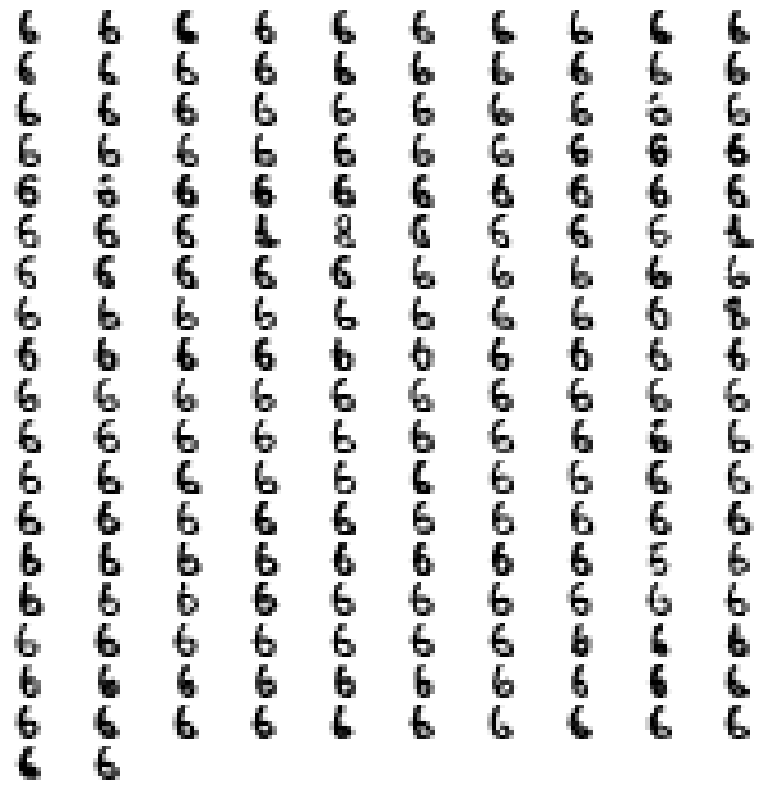

cluster 1
176 elementos


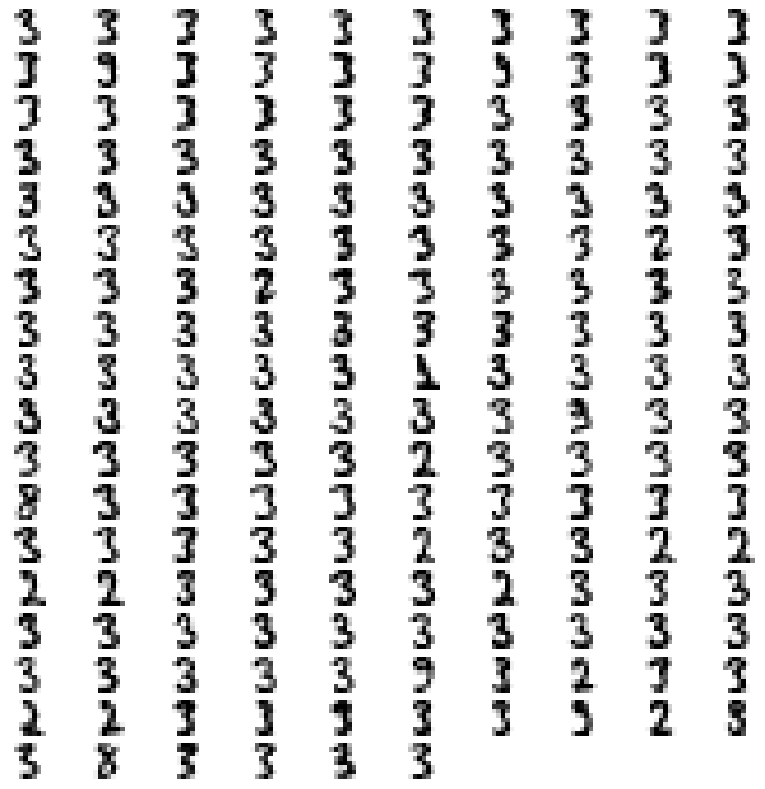

cluster 2
169 elementos


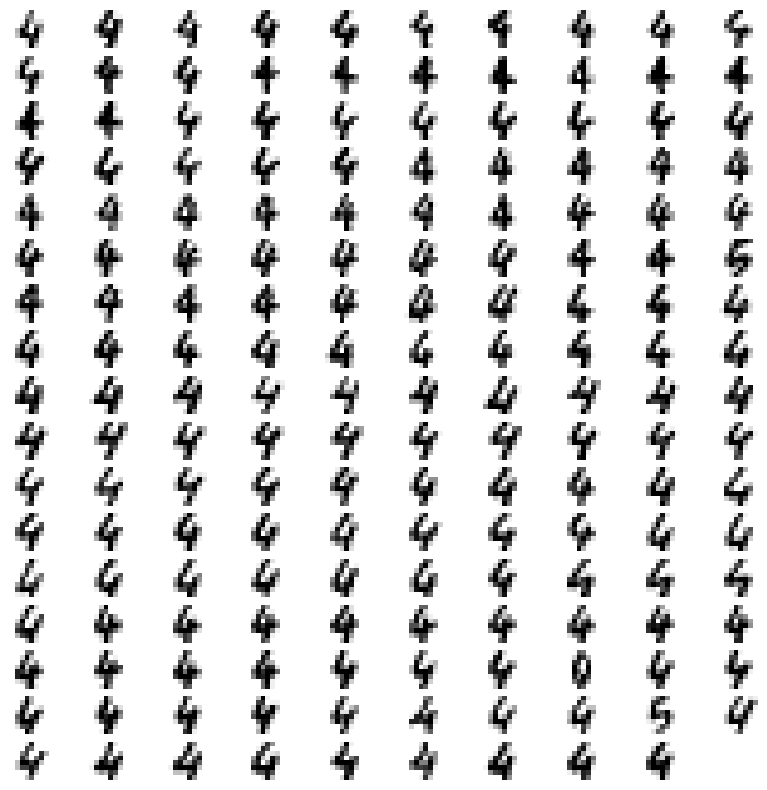

cluster 3
248 elementos


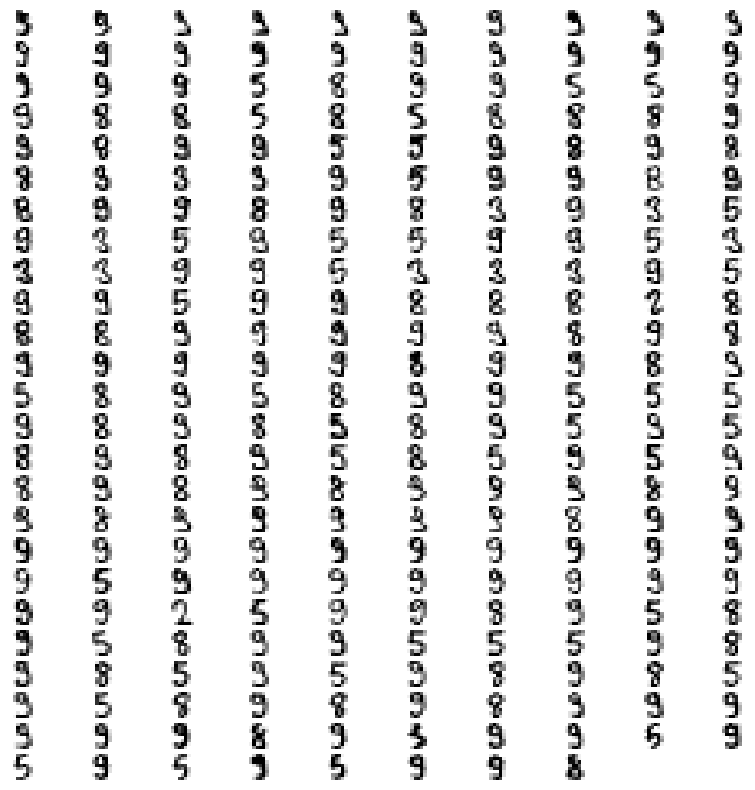

cluster 4
223 elementos


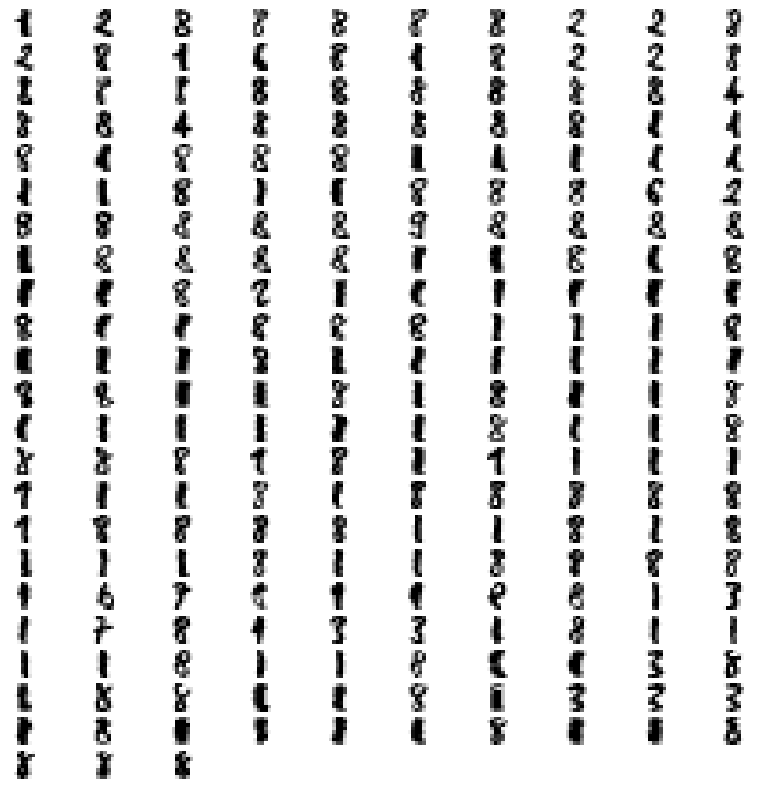

cluster 5
149 elementos


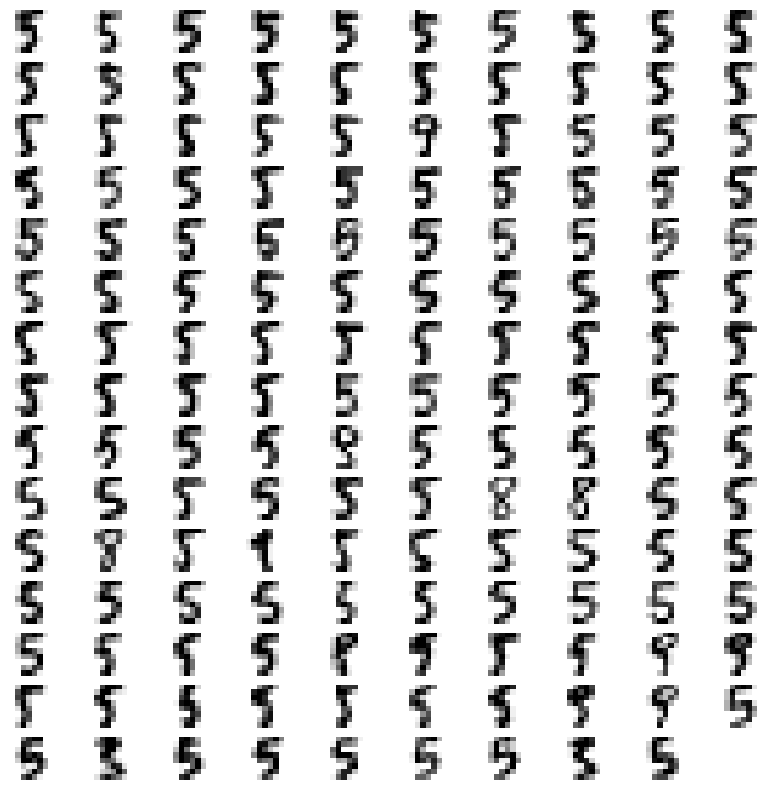

cluster 6
174 elementos


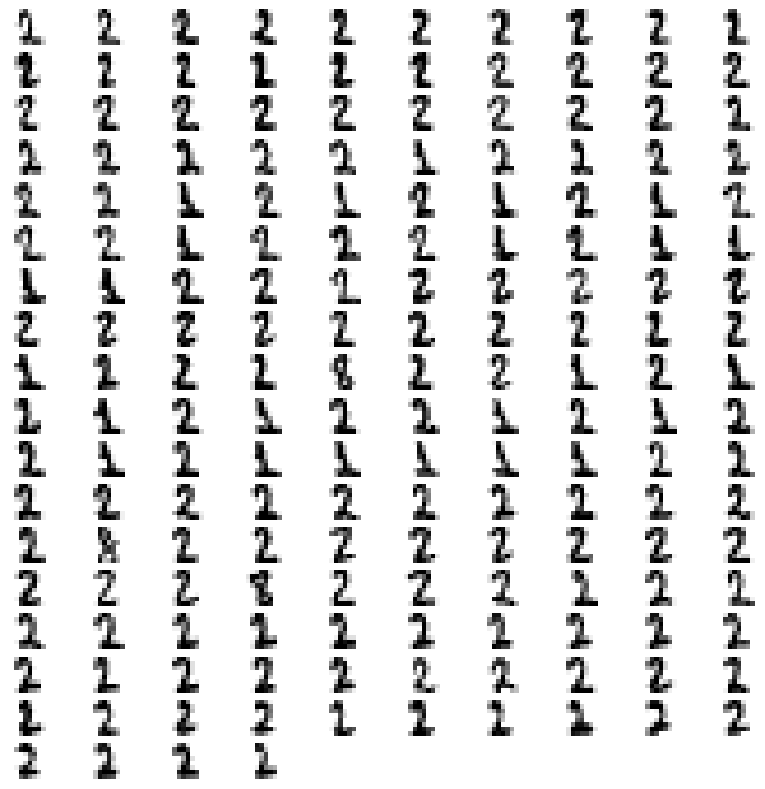

cluster 7
209 elementos


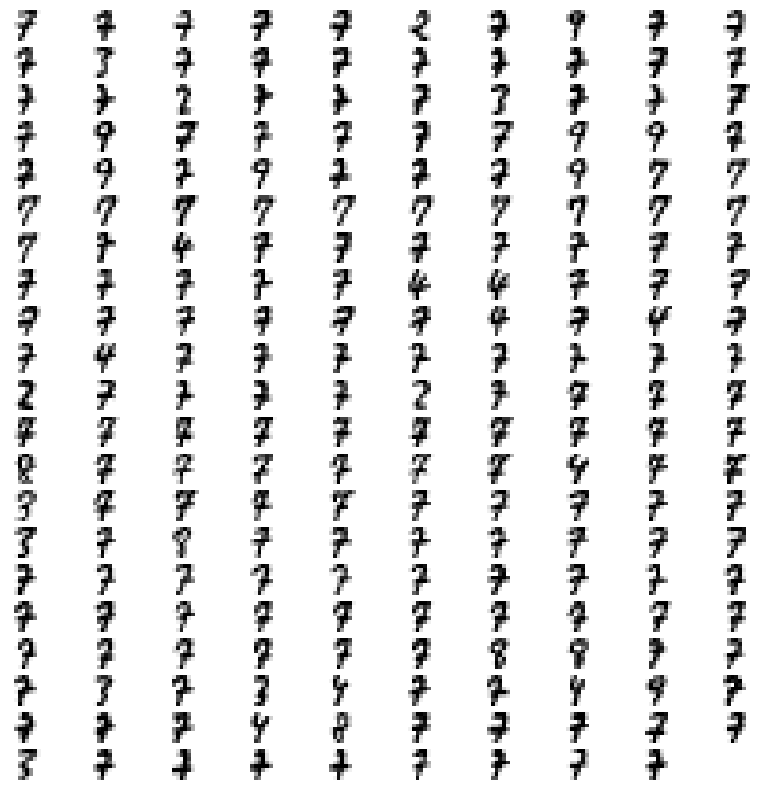

cluster 8
88 elementos


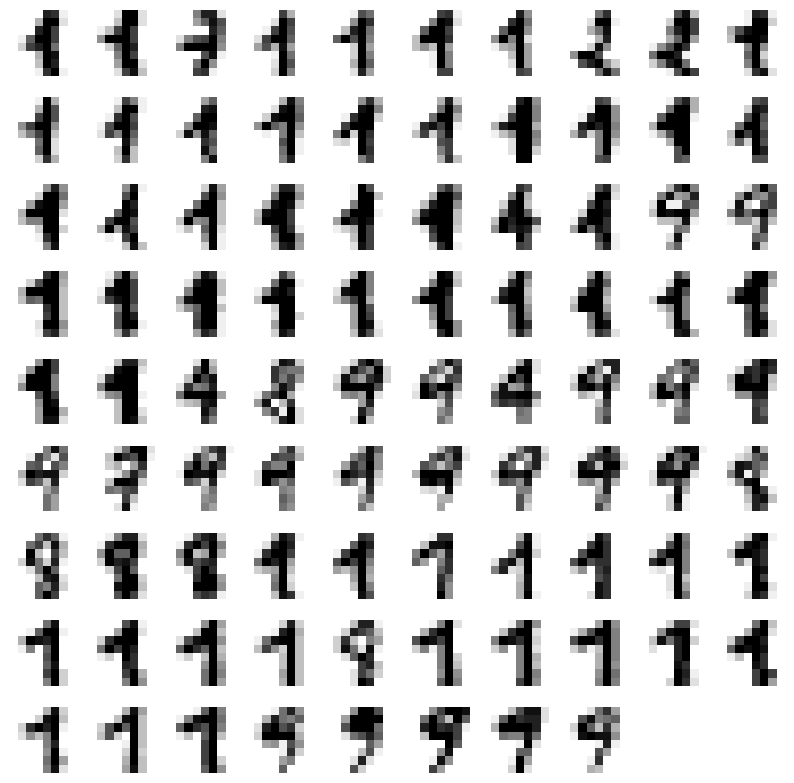

cluster 9
179 elementos


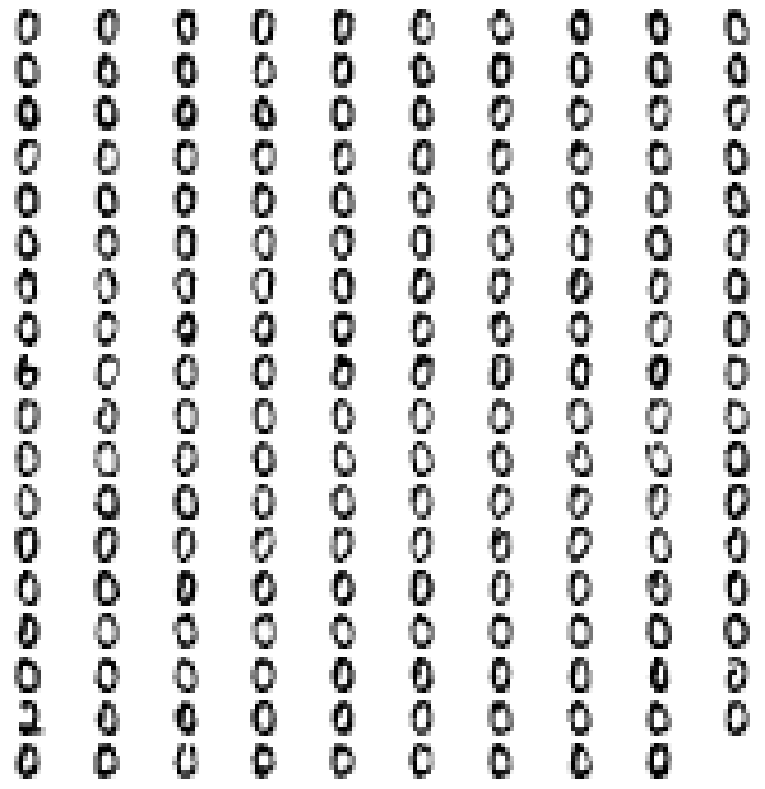

In [98]:
for i in range(0,10):

    fila = np.where(predict==i)[0]   # filas en predict donde están las imágenes de cada cluster
    num = fila.shape[0]              # número imagenes de cada cluster
    r = np.floor(num/10.)            # número de filas menos 1 en figura de salida

    print("cluster "+str(i))
    print(str(num)+" elementos")

    plt.figure(figsize=(10,10))
    for k in range(0, num):
        plt.subplot(int(r+1), 10, k+1)
        imagen = data[fila[k], ]
        imagen = imagen.reshape(8, 8)
        plt.imshow(imagen, cmap=plt.cm.gray)
        plt.axis('off')
    plt.show()

In [ ]:
%%html
<center><marquee style='width: 60%; color: blue;'><b>Muchas gracias por asistir a la clase</b></marquee><center>